In [3]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "alexandra.maria03030@gmail.com"

def fetch_by_ids(id_dict, output_file="sequences.fasta"):
    sequences = []
    
    for organism, seq_id in id_dict.items():
        print(f"Fetching {organism} ({seq_id})...")
        
        fetch_handle = Entrez.efetch(db="protein", id=seq_id, rettype="fasta", retmode="text")
        record = SeqIO.read(fetch_handle, "fasta")
        fetch_handle.close()
        sequences.append(record)
        print(f"  Got it: {record.description[:60]}...")
        time.sleep(0.5)  
    
    SeqIO.write(sequences, output_file, "fasta")
    print(f"\nSaved {len(sequences)} sequences to sequences.fasta")
    return sequences

ids = {
    "Homo sapiens":      "NP_000787.1",
    "Mus musculus":      "NP_034191.2",
    "Rattus norvegicus": "NP_036867.1",
    "Danio rerio":       "NP_922917.1",
    "Gallus gallus":     "NP_001001461.1"
}

sequences = fetch_by_ids(ids)

Fetching Homo sapiens (NP_000787.1)...
  Got it: NP_000787.1 dopamine receptor D3 isoform a [Homo sapiens]...
Fetching Mus musculus (NP_034191.2)...
  Got it: NP_034191.2 deoxyribonuclease I [Mus musculus]...
Fetching Rattus norvegicus (NP_036867.1)...
  Got it: NP_036867.1 hexokinase-2 [Rattus norvegicus]...
Fetching Danio rerio (NP_922917.1)...
  Got it: NP_922917.1 dopamine receptor D2 like [Danio rerio]...
Fetching Gallus gallus (NP_001001461.1)...
  Got it: NP_001001461.1 growth/differentiation factor 8 precursor [Ga...

Saved 5 sequences to sequences.fasta


In [9]:
from Bio import AlignIO, SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import subprocess
import os

MUSCLE_PATH = r"C:\muscle\muscle.exe"

def align_sequences(input_file="sequences.fasta", output_file="aligned.fasta"):
    print("Running MUSCLE alignment...")
    
    result = subprocess.run(
        f'"{MUSCLE_PATH}" -in {input_file} -out {output_file}',
        shell=True, capture_output=True, text=True
    )
    
    if os.path.exists(output_file):
        alignment = AlignIO.read(output_file, "fasta")
        print(f"Alignment done!")
        print(f"Number of sequences: {len(alignment)}")
        print(f"Alignment length: {alignment.get_alignment_length()} amino acids")
        print("\nFirst 80 columns:")
        for record in alignment:
            species = record.description.split("[")[-1].replace("]", "")
            print(f"  {species:<22} {str(record.seq[:80])}")
        return alignment
    else:
        print("Something went wrong. Error message:")
        print(result.stderr)

alignment = align_sequences()

Running MUSCLE alignment...
Alignment done!
Number of sequences: 5
Alignment length: 925 amino acids

First 80 columns:
  Gallus gallus          ---------------------------MQKLAVYVYIYLFMQIAVDPVALDGSSQPTENA--------------------
  Mus musculus           --------------------------------------------------------------------------------
  Rattus norvegicus      MIASHMIACLFTELNQNQVQKVDQFLYHMRLSDETLLEISRRFRKEMEKGLGATTHPTAAVKMLPTFVRSTPDGTEHGEF
  Homo sapiens           ------------------------------MASLSQLSSHLNYTCGAENSTGASQARPHA-------------------Y
  Danio rerio            -------------------MPVLNVTEELTITASPSSAVFLSLHQSNCSVSPSPSSPPYN-------------------F


Building phylogenetic tree...
Distance matrix (lower = more similar):
NP_001001461.1  0.000000
NP_034191.2 0.987721    0.000000
NP_036867.1 1.003027    0.896787    0.000000
NP_000787.1 0.995402    0.945626    0.873970    0.000000
NP_922917.1 1.018161    0.949425    0.939234    0.486275    0.000000
    NP_001001461.1  NP_034191.2 NP_036867.1 NP_000787.1 NP_922917.1

Tree saved to tree.nwk


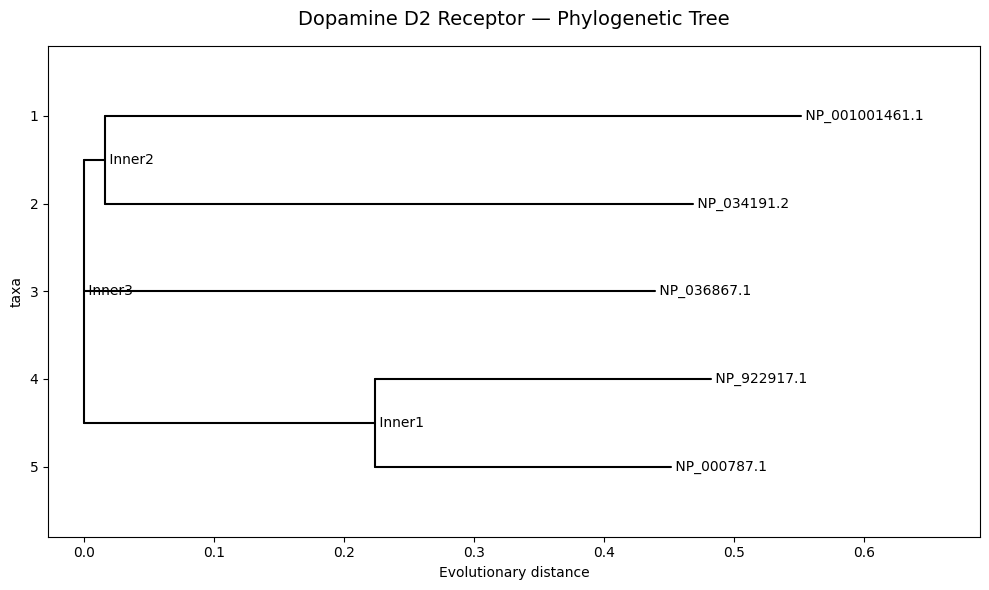

Tree image saved to phylogenetic_tree.png


In [10]:
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt

def build_tree(alignment, output_file="tree.nwk"):
    print("Building phylogenetic tree...")
    
    # Step 1 - calculate how different each sequence is from the others
    calculator = DistanceCalculator("blosum62")
    distance_matrix = calculator.get_distance(alignment)
    
    print("Distance matrix (lower = more similar):")
    print(distance_matrix)
    
    # Step 2 - build the tree from those distances
    constructor = DistanceTreeConstructor(calculator, "nj")
    tree = constructor.build_tree(alignment)
    
    # Step 3 - save the tree to a file
    Phylo.write(tree, output_file, "newick")
    print(f"\nTree saved to {output_file}")
    
    # Step 4 - draw it
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Clean up the species names for display
    for leaf in tree.get_terminals():
        leaf.name = leaf.name.split("[")[-1].replace("]", "").strip()
    
    Phylo.draw(tree, axes=ax, do_show=False)
    ax.set_title("Dopamine D2 Receptor — Phylogenetic Tree", fontsize=14, pad=15)
    ax.set_xlabel("Evolutionary distance")
    plt.tight_layout()
    plt.savefig("phylogenetic_tree.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Tree image saved to phylogenetic_tree.png")
    
    return tree

tree = build_tree(alignment)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_conservation_heatmap(alignment):
    print("Generating conservation heatmap...")
    
    records = list(alignment)
    num_sequences = len(records)
    align_len = alignment.get_alignment_length()
    
    # Build a matrix of 1s and 0s — 1 means all species match at that position
    conservation = []
    for i in range(align_len):
        column = [record.seq[i] for record in records]
        column_no_gaps = [aa for aa in column if aa != "-"]
        if len(column_no_gaps) == 0:
            conservation.append(0)
        else:
            # Score = fraction of sequences that match the most common amino acid
            most_common = max(set(column_no_gaps), key=column_no_gaps.count)
            score = column_no_gaps.count(most_common) / len(column_no_gaps)
            conservation.append(score)
    
    # Smooth into windows of 10 for readability
    window = 10
    smoothed = [
        np.mean(conservation[i:i+window])
        for i in range(0, len(conservation) - window, window)
    ]
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Top plot — conservation score across the sequence
    positions = range(len(smoothed))
    colors = ["#2ecc71" if s > 0.8 else "#e67e22" if s > 0.5 else "#e74c3c" for s in smoothed]
    ax1.bar(positions, smoothed, color=colors, width=1.0, edgecolor="none")
    ax1.axhline(y=0.8, color="gray", linestyle="--", linewidth=0.8, label="80% conservation threshold")
    ax1.set_xlabel("Sequence position (windows of 10 aa)", fontsize=11)
    ax1.set_ylabel("Conservation score", fontsize=11)
    ax1.set_title("Dopamine D2 Receptor — Sequence Conservation Across 5 Species", fontsize=13)
    ax1.set_ylim(0, 1.05)
    ax1.legend()
    
    # Bottom plot — pairwise identity matrix between all species
    species_names = [r.description.split("[")[-1].replace("]","").strip() for r in records]
    identity_matrix = np.zeros((num_sequences, num_sequences))
    
    for i in range(num_sequences):
        for j in range(num_sequences):
            seq_i = str(records[i].seq)
            seq_j = str(records[j].seq)
            matches = sum(a == b and a != "-" for a, b in zip(seq_i, seq_j))
            total = sum(1 for a, b in zip(seq_i, seq_j) if a != "-" and b != "-")
            identity_matrix[i][j] = matches / total if total > 0 else 0
    
    im = ax2.imshow(identity_matrix, cmap="YlGn", vmin=0.5, vmax=1.0)
    ax2.set_xticks(range(num_sequences))
    ax2.set_yticks(range(num_sequences))
    ax2.set_xticklabels(species_names, rotation=30, ha="right", fontsize=10)
    ax2.set_yticklabels(species_names, fontsize=10)
    ax2.set_title("Pairwise sequence identity between species", fontsize=13)
    plt.colorbar(im, ax=ax2, label="Identity score")
    
    # Add percentage labels inside each cell
    for i in range(num_sequences):
        for j in range(num_sequences):
            ax2.text(j, i, f"{identity_matrix[i][j]:.0%}",
                    ha="center", va="center", fontsize=10,
                    color="black" if identity_matrix[i][j] < 0.9 else "white")
    
    plt.tight_layout()
    plt.savefig("conservation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to conservation_heatmap.png")

plot_conservation_heatmap(alignment)

Generating conservation heatmap...
Saved to conservation_heatmap.png


C:\Users\alexa\AppData\Local\Temp\ipykernel_23684\791918359.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
